In [1]:
!pip install -q scikit-learn tensorflow joblib nltk Sastrawi tqdm pandas numpy matplotlib seaborn wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.7 MB/s eta 0:00:00


## 1. EDA, Preprocessing & Labeling

In [70]:
# import lib
import os
import re
import json
import string
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pickle

from collections import Counter
from wordcloud import WordCloud
from tqdm import tqdm
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score, recall_score, f1_score)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, GRU, Bidirectional,
                                      Dense, Dropout, SpatialDropout1D)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import load_model

warnings.filterwarnings('ignore')
tqdm.pandas()

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


os.makedirs('models', exist_ok=True)

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

print("Import selesai.")
print(f"TensorFlow version: {tf.__version__}")


Import selesai.
TensorFlow version: 2.20.0


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
# load datasate
df = pd.read_csv('raw_reviews_newsakpole.csv')

In [5]:
# Menampilkan lima data teratas.
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,a9116c12-e4fd-44a7-b47d-2aa5d7124a85,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Aplikasi bermasalah.Error saat mau masuk menu ...,1,10,3.1.4,2026-04-17 05:59:26,NaN,NaN,3.1.4
1,af1edd25-923f-45bb-b493-65c2cedb6530,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,aplikasi membantu cek brp pembayaran pajaknya....,5,0,3.1.4,2026-05-20 04:17:50,NaN,NaN,3.1.4
2,4e0142ea-2466-4cc8-bed5-041e80a2d772,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kenapa blm masuk juga padahal suda bayar Lo in...,1,2,3.1.4,2026-05-15 13:49:39,NaN,NaN,3.1.4
3,519db25e-4342-438f-96c3-9b1f2e80e0ed,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"jelek banget sii pelayanannya, beda banget kal...",1,5,3.1.4,2026-05-02 03:13:38,NaN,NaN,3.1.4
4,04514bcd-63df-4c76-adb3-95194a09b767,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Seperti biasa, aplikasi instansi pemerintah BU...",1,0,3.1.4,2026-05-23 03:39:02,NaN,NaN,3.1.4


In [6]:
print(df.isnull().sum())
print(f"Jumlah duplikat: {df.duplicated().sum()}")

reviewId                    0
userName                    0
userImage                   0
content                     0
score                       0
thumbsUpCount               0
reviewCreatedVersion     3436
at                          0
replyContent            17339
repliedAt               17339
appVersion               3436
dtype: int64
Jumlah duplikat: 0


In [7]:
print(df.describe(include='all'))

                                    reviewId         userName  \
count                                  17589            17589   
unique                                 17589                1   
top     2ef1ee10-3561-4140-b17a-99aed66a53da  Pengguna Google   
freq                                       1            17589   
mean                                     NaN              NaN   
std                                      NaN              NaN   
min                                      NaN              NaN   
25%                                      NaN              NaN   
50%                                      NaN              NaN   
75%                                      NaN              NaN   
max                                      NaN              NaN   

                                                userImage          content  \
count                                               17589            17589   
unique                                                  1      

In [8]:
SLANG_URL = "https://raw.githubusercontent.com/adeariniputri/text-preprocesing/master/slang.csv"

slang_dict = {}

try:
    slang_df = pd.read_csv(SLANG_URL, header=None, names=['slang', 'formal'])
    slang_dict = dict(zip(slang_df['slang'].str.lower(), slang_df['formal'].str.lower()))
    print(f"Kamus slang berhasil dimuat dari GitHub. Total entri: {len(slang_dict)}")
except Exception as e:
    print(f"Gagal memuat dari GitHub: {e}")
    local_path = 'data/slang_dictionary.csv'
    if os.path.exists(local_path):
        slang_df = pd.read_csv(local_path, header=None, names=['slang', 'formal'])
        slang_dict = dict(zip(slang_df['slang'].str.lower(), slang_df['formal'].str.lower()))
        print(f"Kamus slang dimuat dari lokal: {local_path}. Total entri: {len(slang_dict)}")
    else:
        print("Kamus slang tidak tersedia. Normalisasi slang dilewati.")
        print("Unduh manual dari: https://github.com/adeariniputri/text-preprocesing/blob/master/slang.csv")
        print("Simpan ke: data/slang_dictionary.csv")

Kamus slang berhasil dimuat dari GitHub. Total entri: 1481


In [9]:
# Inisialisasi stemmer dan stopwords
factory = StemmerFactory()
stemmer = factory.create_stemmer()

id_stopwords = set(stopwords.words('indonesian'))
en_stopwords = set(stopwords.words('english'))
all_stopwords = id_stopwords.union(en_stopwords)

# Jangan hapus kata negasi karena penting untuk sentiment analysis
negation_words = {
    'tidak', 'ga', 'gak', 'nggak', 'enggak', 'ngga', 'ngak',
    'bukan', 'jangan', 'belum', 'kurang', 'tak', 'ndak',
    'no', 'not', 'never'
}

all_stopwords = all_stopwords - negation_words

tech_words_keep = {
    'bug', 'bugs', 'error', 'crash', 'forceclose', 'force', 'close',
    'lag', 'laggy', 'lemot', 'loading', 'login', 'logout',
    'server', 'update', 'install', 'uninstall', 'download', 'upload',
    'hang', 'freeze', 'blank', 'delay'
}

def remove_mentions(text):
    return re.sub(r'@\w+', ' ', text)

def remove_hashtags(text):
    return re.sub(r'#\w+', ' ', text)

def remove_rt(text):
    return re.sub(r'\bRT\b', ' ', text)

def remove_urls(text):
    return re.sub(r'http\S+|www\.\S+', ' ', text)

def remove_numbers(text):
    return re.sub(r'\d+', ' ', text)

def remove_punctuation(text):
    return text.translate(str.maketrans(string.punctuation, ' ' * len(string.punctuation)))

def remove_newlines(text):
    return text.replace('\n', ' ').replace('\r', ' ')

def normalize_whitespace(text):
    return re.sub(r'\s+', ' ', text).strip()

def case_folding(text):
    return text.lower()

def normalize_slang(text, slang_dict):
    if not slang_dict:
        return text

    words = text.split()
    normalized_words = []

    for w in words:
        if w in tech_words_keep:
            normalized_words.append(w)
        else:
            normalized_words.append(slang_dict.get(w, w))

    return ' '.join(normalized_words)

# def normalize_slang(text, slang_dict):
#     if not slang_dict:
#         return text
#     words = text.split()
#     return ' '.join([slang_dict.get(w, w) for w in words])

def tokenize(text):
    return word_tokenize(text)

def remove_stopwords(tokens):
    return [t for t in tokens if t not in all_stopwords and len(t) > 1]

def stem_tokens(tokens):
    return [stemmer.stem(t) for t in tokens]

def preprocess_text(text):
    if pd.isna(text) or str(text).strip() == '':
        return ''
    text = str(text)
    text = remove_mentions(text)
    text = remove_hashtags(text)
    text = remove_rt(text)
    text = remove_urls(text)
    text = remove_numbers(text)
    text = remove_punctuation(text)
    text = remove_newlines(text)
    text = normalize_whitespace(text)
    text = case_folding(text)
    text = normalize_slang(text, slang_dict)
    tokens = tokenize(text)
    tokens = remove_stopwords(tokens)
    tokens = stem_tokens(tokens)
    return ' '.join(tokens)

print("Fungsi preprocessing siap.")

Fungsi preprocessing siap.


In [10]:
print("Memulai preprocessing... (mungkin memakan waktu beberapa menit)")
df['clean_text'] = df['content'].progress_apply(preprocess_text)

# Hapus baris dengan clean_text kosong
before = len(df)
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)
after = len(df)
print(f"Baris dihapus karena clean_text kosong: {before - after}")
print(f"Total data setelah cleaning: {after}")
df[['content', 'clean_text']].head(5)

Memulai preprocessing... (mungkin memakan waktu beberapa menit)


100%|██████████| 17589/17589 [14:36<00:00, 20.07it/s]

Baris dihapus karena clean_text kosong: 206
Total data setelah cleaning: 17383


,content,clean_text
0,Aplikasi bermasalah.Error saat mau masuk menu ...,aplikasi masalah error masuk menu bayar kali c...
1,aplikasi membantu cek brp pembayaran pajaknya....,aplikasi bantu cek brp bayar pajak saran bayar...
2,kenapa blm masuk juga padahal suda bayar Lo in...,blm masuk suda bayar tolong tindak lanjut baya...
3,"jelek banget sii pelayanannya, beda banget kal...",jelek sii layan beda pakai apk jaring langsung...
4,"Seperti biasa, aplikasi instansi pemerintah BU...",aplikasi instansi perintah busuk tidak ngecek ...


In [11]:
POS_URL = "https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv"
NEG_URL = "https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv"

def load_lexicon(url, col_word='word', col_weight='weight'):
    try:
        lex_df = pd.read_csv(url)
        print(f"Kolom lexicon: {lex_df.columns.tolist()}")
        # Deteksi kolom otomatis
        word_col = col_word if col_word in lex_df.columns else lex_df.columns[0]
        weight_col = col_weight if col_weight in lex_df.columns else (lex_df.columns[1] if len(lex_df.columns) > 1 else None)
        if weight_col:
            return dict(zip(lex_df[word_col].str.lower(), lex_df[weight_col]))
        else:
            return {w.lower(): 1 for w in lex_df[word_col]}
    except Exception as e:
        print(f"Gagal memuat lexicon dari {url}: {e}")
        return {}

print("Memuat lexicon positif...")
pos_lexicon = load_lexicon(POS_URL)
print(f"Total kata positif: {len(pos_lexicon)}")

print("\nMemuat lexicon negatif...")
neg_lexicon = load_lexicon(NEG_URL)
print(f"Total kata negatif: {len(neg_lexicon)}")

Memuat lexicon positif...
Kolom lexicon: ['hai', '3']
Total kata positif: 3606

Memuat lexicon negatif...
Kolom lexicon: ['putus tali gantung', '-2']
Total kata negatif: 6605


In [12]:
def calculate_sentiment_score(text):
    if not text or str(text).strip() == '':
        return 0
    tokens = str(text).split()
    score = 0
    for token in tokens:
        if token in pos_lexicon:
            score += pos_lexicon[token]
        elif token in neg_lexicon:
            score -= abs(neg_lexicon[token])
    return score

def score_to_label(score):
    if score > 0:
        return 'positive'
    elif score < 0:
        return 'negative'
    else:
        return 'neutral'

print("Menghitung skor sentimen...")
df['sentiment_score'] = df['clean_text'].progress_apply(calculate_sentiment_score)
df['sentiment'] = df['sentiment_score'].apply(score_to_label)

print("\nDistribusi sentimen:")
print(df['sentiment'].value_counts())
print()
print("Persentase:")
print(df['sentiment'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Menghitung skor sentimen...


100%|██████████| 17383/17383 [00:00<00:00, 303853.25it/s]


Distribusi sentimen:
sentiment
negative    10380
positive     5349
neutral      1654
Name: count, dtype: int64

Persentase:
sentiment
negative    59.71%
positive    30.77%
neutral      9.52%
Name: proportion, dtype: object


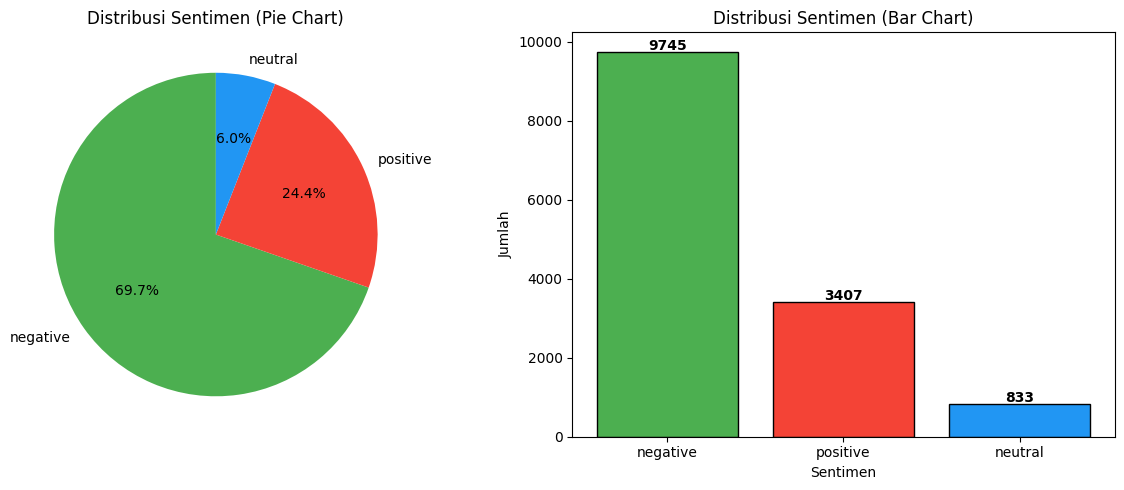

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sentiment_counts = df['sentiment'].value_counts()
colors = ['#4CAF50', '#F44336', '#2196F3']

# Pie chart
axes[0].pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[0].set_title('Distribusi Sentimen (Pie Chart)')

# Bar chart
axes[1].bar(sentiment_counts.index, sentiment_counts.values, color=colors, edgecolor='black')
axes[1].set_title('Distribusi Sentimen (Bar Chart)')
axes[1].set_xlabel('Sentimen')
axes[1].set_ylabel('Jumlah')
for i, v in enumerate(sentiment_counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('visualizations/sentiment_distribution.png', dpi=100)
plt.show()

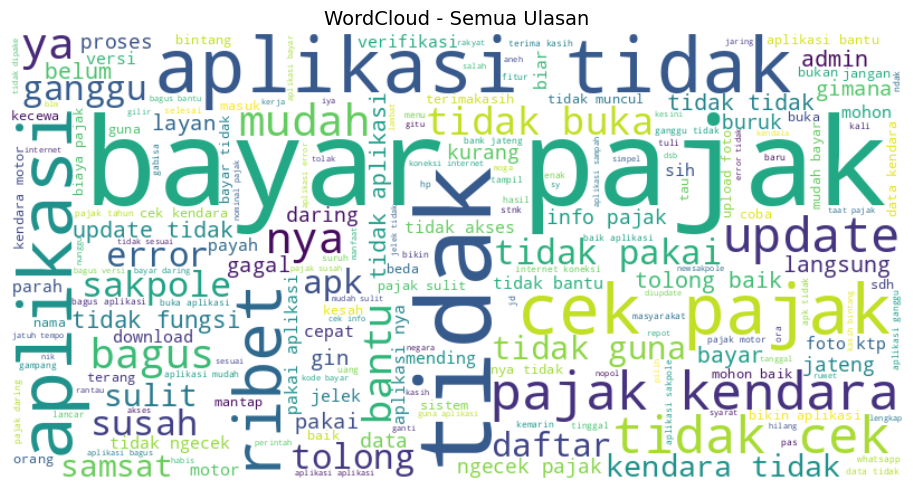

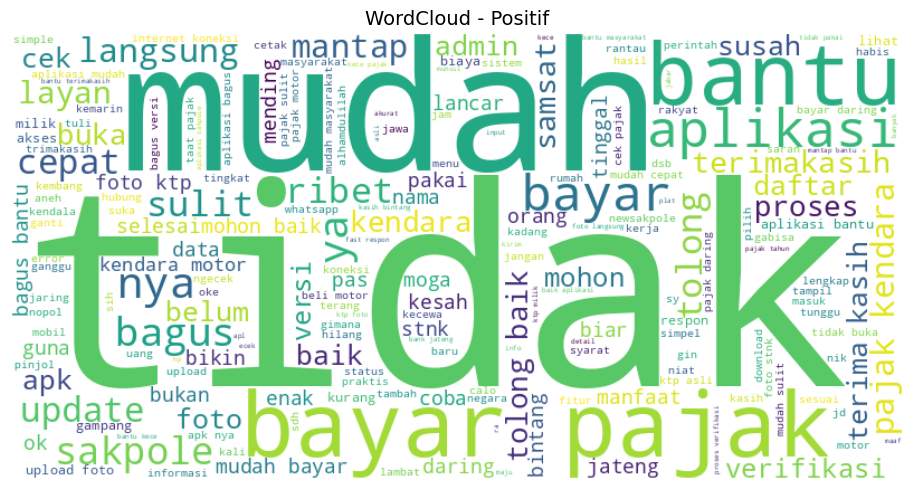

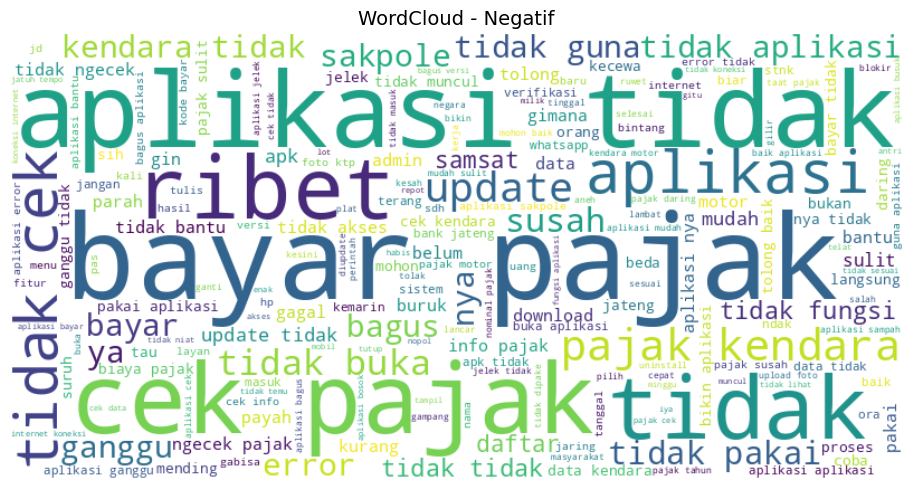

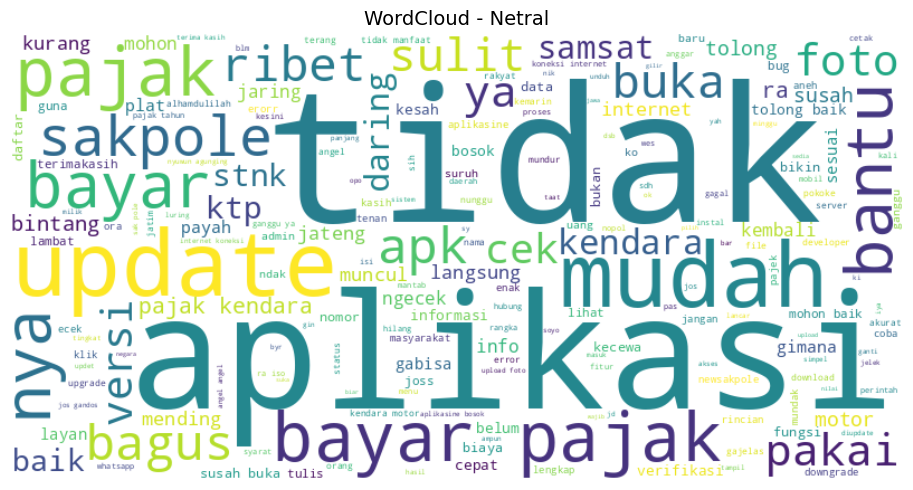

In [20]:
def generate_wordcloud(text_series, title, save_path):
    all_text = ' '.join(text_series.dropna().astype(str))
    if not all_text.strip():
        print(f"Tidak ada teks untuk: {title}")
        return
    wc = WordCloud(width=800, height=400, background_color='white',
                   max_words=200, colormap='viridis').generate(all_text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path, dpi=100)
    plt.show()

generate_wordcloud(df['clean_text'], 'WordCloud - Semua Ulasan',
                   'visualizations/wc_all.png')
generate_wordcloud(df[df['sentiment']=='positive']['clean_text'], 'WordCloud - Positif',
                   'visualizations/wc_positive.png')
generate_wordcloud(df[df['sentiment']=='negative']['clean_text'], 'WordCloud - Negatif',
                   'visualizations/wc_negative.png')
generate_wordcloud(df[df['sentiment']=='neutral']['clean_text'], 'WordCloud - Netral',
                   'visualizations/wc_neutral.png')

In [21]:
os.makedirs('data', exist_ok=True)

# Cleaned
df_cleaned = df.copy()
df_cleaned.to_csv('cleaned_reviews_new_sakpole.csv', index=False, encoding='utf-8-sig')
print("Saved: cleaned_reviews_new_sakpole.csv")

# Labeled
df_labeled = df[['content', 'clean_text', 'sentiment_score', 'sentiment']].copy()
if 'score' in df.columns:
    df_labeled['score'] = df['score']
if 'at' in df.columns:
    df_labeled['at'] = df['at']
df_labeled.to_csv('labeled_reviews_new_sakpole.csv', index=False, encoding='utf-8-sig')
print("Saved: labeled_reviews_new_sakpole.csv")

# Final - kolom lengkap yang dibutuhkan training
keep_cols = ['content', 'clean_text', 'sentiment_score', 'sentiment']
for extra in ['score', 'at', 'userName', 'thumbsUpCount']:
    if extra in df.columns:
        keep_cols.append(extra)
df_final = df[keep_cols].copy()
df_final.to_csv('final_reviews_new_sakpole.csv', index=False, encoding='utf-8-sig')
print("Saved: final_reviews_new_sakpole.csv")

print(f"\nTotal data final: {len(df_final)}")
print(df_final['sentiment'].value_counts())

Saved: cleaned_reviews_new_sakpole.csv
Saved: labeled_reviews_new_sakpole.csv
Saved: final_reviews_new_sakpole.csv

Total data final: 13985
sentiment
negative    9745
positive    3407
neutral      833
Name: count, dtype: int64


## 2. Model Training (3 Skema)

In [22]:
# Hapus baris dengan clean_text kosong atau sentiment kosong
df = df.dropna(subset=['clean_text', 'sentiment'])
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)

# Filter teks terlalu pendek (kurang dari 2 kata)
df = df[df['clean_text'].apply(lambda x: len(str(x).split()) >= 2)].reset_index(drop=True)

print(f"Total data setelah filter: {len(df)}")
print(df['sentiment'].value_counts())

Total data setelah filter: 13985
sentiment
negative    9745
positive    3407
neutral      833
Name: count, dtype: int64


In [26]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])

print("Mapping label:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} -> {cls}")

NUM_CLASSES = len(le.classes_)
print(f"\nJumlah kelas: {NUM_CLASSES}")

Mapping label:
  0 -> negative
  1 -> neutral
  2 -> positive

Jumlah kelas: 3


In [32]:
X = df['clean_text'].astype(str)
y = df['label']

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"Train: {len(X_train1)} | Test: {len(X_test1)}")

Train: 11188 | Test: 2797


In [33]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train1_tfidf = tfidf.fit_transform(X_train1)
X_test1_tfidf  = tfidf.transform(X_test1)
print(f"TF-IDF shape train: {X_train1_tfidf.shape}")

TF-IDF shape train: (11188, 10000)


In [34]:
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    C=1.0,
    solver='lbfgs',
    multi_class='multinomial',
    random_state=SEED
)
lr_model.fit(X_train1_tfidf, y_train1)

train_acc1 = accuracy_score(y_train1, lr_model.predict(X_train1_tfidf))
y_pred1    = lr_model.predict(X_test1_tfidf)
test_acc1  = accuracy_score(y_test1, y_pred1)

print(f"Train Accuracy : {train_acc1:.4f}")
print(f"Test  Accuracy : {test_acc1:.4f}")
print()
print(classification_report(y_test1, y_pred1, target_names=le.classes_))

Train Accuracy : 0.9474
Test  Accuracy : 0.8738

              precision    recall  f1-score   support

    negative       0.97      0.90      0.93      1949
     neutral       0.39      0.59      0.47       167
    positive       0.80      0.87      0.83       681

    accuracy                           0.87      2797
   macro avg       0.72      0.79      0.75      2797
weighted avg       0.89      0.87      0.88      2797



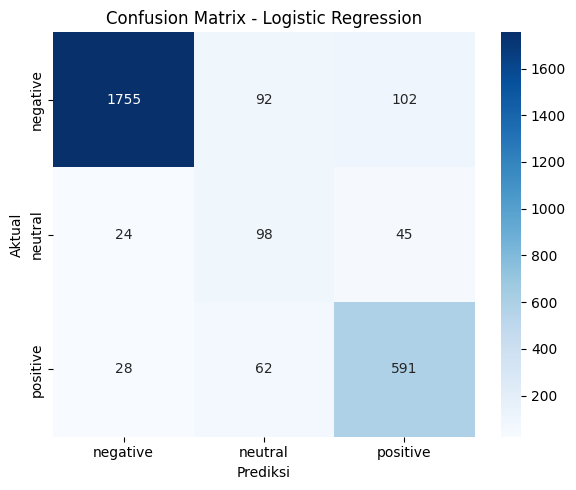

In [35]:
cm1 = confusion_matrix(y_test1, y_pred1)
plt.figure(figsize=(6, 5))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.tight_layout()
plt.savefig('visualizations/cm_logreg.png', dpi=100)
plt.show()

In [43]:
# Simpan artefak Skema 1
joblib.dump(lr_model, 'models/model_logreg.joblib')
joblib.dump(tfidf,    'models/vectorizer_tfidf.joblib')
joblib.dump(le,       'models/label_encoder.joblib')
print("Artefak Skema 1 tersimpan.")

Artefak Skema 1 tersimpan.


BiLSTM 80/20

In [44]:
MAX_FEATURES = 10000
MAX_LEN      = 50
EMBED_DIM    = 128
BATCH_SIZE   = 512
EPOCHS       = 20

X2 = df['clean_text'].astype(str).values
y2 = df['label'].values

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=SEED, stratify=y2
)
print(f"Train: {len(X_train2)} | Test: {len(X_test2)}")

Train: 11188 | Test: 2797


In [45]:
tokenizer = Tokenizer(num_words=MAX_FEATURES, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train2)

X_train2_seq = pad_sequences(tokenizer.texts_to_sequences(X_train2), maxlen=MAX_LEN, padding='post', truncating='post')
X_test2_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test2),  maxlen=MAX_LEN, padding='post', truncating='post')

y_train2_cat = to_categorical(y_train2, NUM_CLASSES)
y_test2_cat  = to_categorical(y_test2,  NUM_CLASSES)

print(f"Sequence shape train: {X_train2_seq.shape}")

Sequence shape train: (11188, 50)


In [46]:
def build_bilstm(vocab_size, embed_dim, max_len, num_classes):
    model = Sequential([
        Embedding(vocab_size, embed_dim, input_length=max_len),
        SpatialDropout1D(0.3),
        Bidirectional(LSTM(128, return_sequences=True)),
        Bidirectional(LSTM(64)),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

bilstm_model = build_bilstm(MAX_FEATURES + 1, EMBED_DIM, MAX_LEN, NUM_CLASSES)
bilstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [47]:
callbacks2 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)
]

history2 = bilstm_model.fit(
    X_train2_seq, y_train2_cat,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks2,
    verbose=1
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.6737 - loss: 0.8201 - val_accuracy: 0.6997 - val_loss: 0.6992 - learning_rate: 0.0010
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.7713 - loss: 0.5860 - val_accuracy: 0.8427 - val_loss: 0.4273 - learning_rate: 0.0010
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.8556 - loss: 0.3969 - val_accuracy: 0.8811 - val_loss: 0.3095 - learning_rate: 0.0010
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9049 - loss: 0.2561 - val_accuracy: 0.9080 - val_loss: 0.2550 - learning_rate: 0.0010
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.9367 - loss: 0.1761 - val_accuracy: 0.9160 - val_loss: 0.2357 - learning_rate: 0.0010
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.9506 - loss: 0.1398 - val_accuracy: 0.9276 - val_loss: 0.2037 - learning_rate: 0.0010
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.9602 - loss: 0.1180 - val_accuracy: 

In [48]:
train_loss2, train_acc2 = bilstm_model.evaluate(X_train2_seq, y_train2_cat, verbose=0)
test_loss2,  test_acc2  = bilstm_model.evaluate(X_test2_seq,  y_test2_cat,  verbose=0)

y_pred2 = np.argmax(bilstm_model.predict(X_test2_seq, verbose=0), axis=1)

print(f"Train Accuracy : {train_acc2:.4f}")
print(f"Test  Accuracy : {test_acc2:.4f}")
print()
print(classification_report(y_test2, y_pred2, target_names=le.classes_))

Train Accuracy : 0.9612
Test  Accuracy : 0.9217

              precision    recall  f1-score   support

    negative       0.97      0.94      0.96      1949
     neutral       0.59      0.59      0.59       167
    positive       0.86      0.94      0.90       681

    accuracy                           0.92      2797
   macro avg       0.81      0.83      0.82      2797
weighted avg       0.92      0.92      0.92      2797



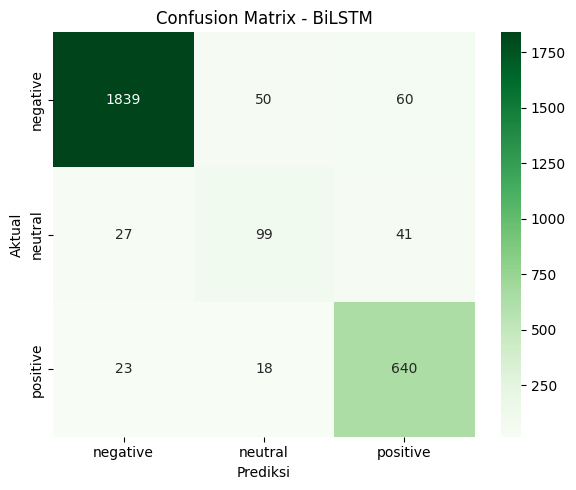

In [49]:
cm2 = confusion_matrix(y_test2, y_pred2)
plt.figure(figsize=(6, 5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - BiLSTM')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.tight_layout()
plt.savefig('visualizations/cm_bilstm.png', dpi=100)
plt.show()

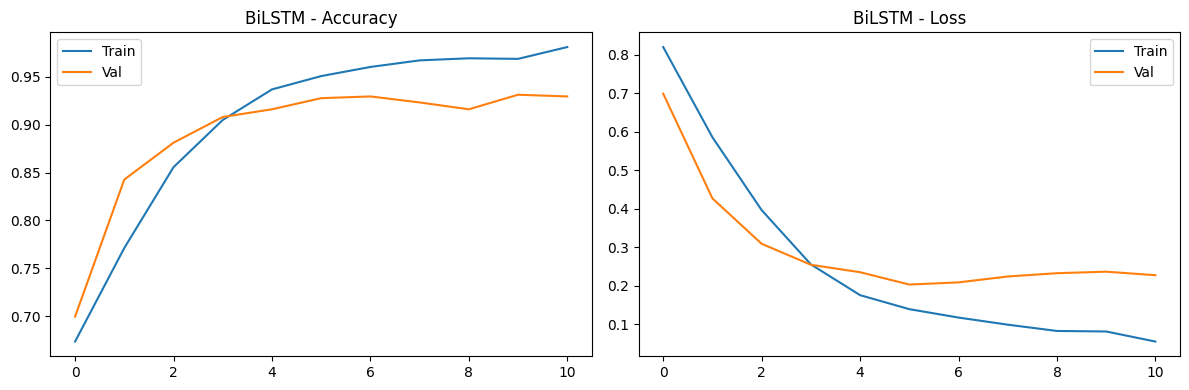

In [50]:
# Plot training history BiLSTM
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history2.history['accuracy'], label='Train')
axes[0].plot(history2.history['val_accuracy'], label='Val')
axes[0].set_title('BiLSTM - Accuracy')
axes[0].legend()
axes[1].plot(history2.history['loss'], label='Train')
axes[1].plot(history2.history['val_loss'], label='Val')
axes[1].set_title('BiLSTM - Loss')
axes[1].legend()
plt.tight_layout()
plt.savefig('visualizations/history_bilstm.png', dpi=100)
plt.show()

In [55]:
bilstm_model.save('models/model_bilstm.keras')
with open('models/tokenizer_bilstm.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("Artefak Skema 2 tersimpan.")

Artefak Skema 2 tersimpan.


Skema 3 - BiGRU

In [56]:
X3 = df['clean_text'].astype(str).values
y3 = df['label'].values

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3, y3, test_size=0.3, random_state=SEED, stratify=y3
)
print(f"Train: {len(X_train3)} | Test: {len(X_test3)}")

Train: 9789 | Test: 4196


In [57]:
tokenizer3 = Tokenizer(num_words=MAX_FEATURES, oov_token='<OOV>')
tokenizer3.fit_on_texts(X_train3)

X_train3_seq = pad_sequences(tokenizer3.texts_to_sequences(X_train3), maxlen=MAX_LEN, padding='post', truncating='post')
X_test3_seq  = pad_sequences(tokenizer3.texts_to_sequences(X_test3),  maxlen=MAX_LEN, padding='post', truncating='post')

y_train3_cat = to_categorical(y_train3, NUM_CLASSES)
y_test3_cat  = to_categorical(y_test3,  NUM_CLASSES)

print(f"Sequence shape train: {X_train3_seq.shape}")

Sequence shape train: (9789, 50)


In [58]:
def build_bigru(vocab_size, embed_dim, max_len, num_classes):
    model = Sequential([
        Embedding(vocab_size, embed_dim, input_length=max_len),
        SpatialDropout1D(0.3),
        Bidirectional(GRU(128, return_sequences=True)),
        Bidirectional(GRU(64)),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

bigru_model = build_bigru(MAX_FEATURES + 1, EMBED_DIM, MAX_LEN, NUM_CLASSES)
bigru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [59]:
callbacks3 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)
]

history3 = bigru_model.fit(
    X_train3_seq, y_train3_cat,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks3,
    verbose=1
)

Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.6734 - loss: 0.8177 - val_accuracy: 0.7743 - val_loss: 0.5669 - learning_rate: 0.0010
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.8081 - loss: 0.5345 - val_accuracy: 0.8468 - val_loss: 0.3948 - learning_rate: 0.0010
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.8704 - loss: 0.3589 - val_accuracy: 0.8887 - val_loss: 0.2954 - learning_rate: 0.0010
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.9170 - loss: 0.2207 - val_accuracy: 0.9152 - val_loss: 0.2629 - learning_rate: 0.0010
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9403 - loss: 0.1589 - val_accuracy: 0.9295 - val_loss: 0.2179 - learning_rate: 0.0010
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.9589 - loss: 0.1116 - val_accuracy: 0.9193 - val_loss: 0.2753 - learning_rate: 0.0010
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.9657 - loss: 0.0899 - val_accuracy: 

In [60]:
train_loss3, train_acc3 = bigru_model.evaluate(X_train3_seq, y_train3_cat, verbose=0)
test_loss3,  test_acc3  = bigru_model.evaluate(X_test3_seq,  y_test3_cat,  verbose=0)

y_pred3 = np.argmax(bigru_model.predict(X_test3_seq, verbose=0), axis=1)

print(f"Train Accuracy : {train_acc3:.4f}")
print(f"Test  Accuracy : {test_acc3:.4f}")
print()
print(classification_report(y_test3, y_pred3, target_names=le.classes_))

Train Accuracy : 0.9594
Test  Accuracy : 0.9202

              precision    recall  f1-score   support

    negative       0.95      0.97      0.96      2924
     neutral       0.64      0.53      0.58       250
    positive       0.88      0.87      0.88      1022

    accuracy                           0.92      4196
   macro avg       0.82      0.79      0.81      4196
weighted avg       0.92      0.92      0.92      4196



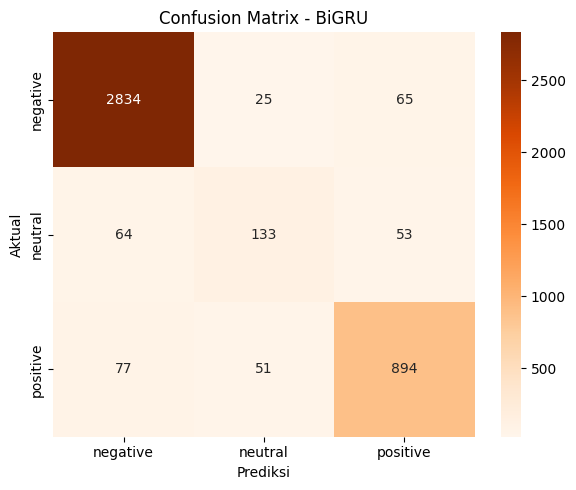

In [61]:
cm3 = confusion_matrix(y_test3, y_pred3)
plt.figure(figsize=(6, 5))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - BiGRU')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.tight_layout()
plt.savefig('visualizations/cm_bigru.png', dpi=100)
plt.show()

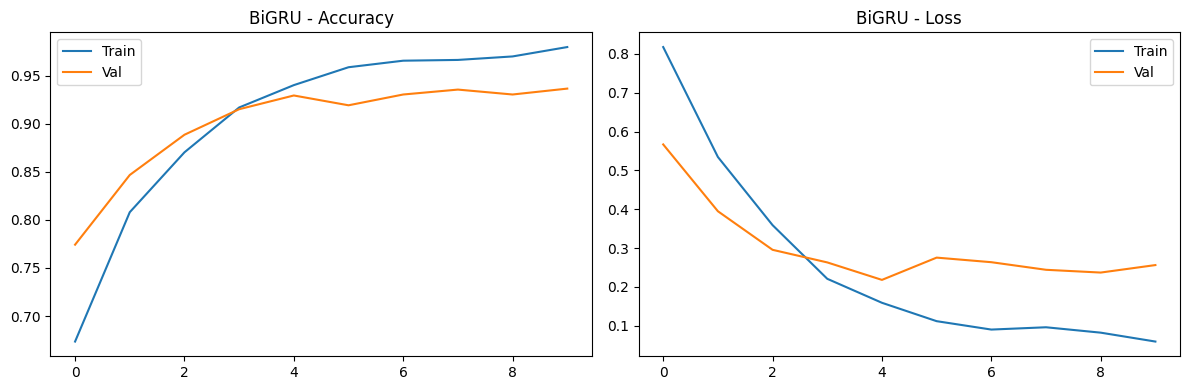

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history3.history['accuracy'], label='Train')
axes[0].plot(history3.history['val_accuracy'], label='Val')
axes[0].set_title('BiGRU - Accuracy')
axes[0].legend()
axes[1].plot(history3.history['loss'], label='Train')
axes[1].plot(history3.history['val_loss'], label='Val')
axes[1].set_title('BiGRU - Loss')
axes[1].legend()
plt.tight_layout()
plt.savefig('visualizations/history_bigru.png', dpi=100)
plt.show()

In [63]:
bigru_model.save('models/model_bigru.keras')
with open('models/tokenizer_bigru.pkl', 'wb') as f:
    pickle.dump(tokenizer3, f)
print("Artefak Skema 3 tersimpan.")

Artefak Skema 3 tersimpan.


Perbandingan Model

In [64]:
def get_metrics(y_true, y_pred):
    return {
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro':    recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_macro':        f1_score(y_true, y_pred, average='macro', zero_division=0),
    }

m1 = get_metrics(y_test1, y_pred1)
m2 = get_metrics(y_test2, y_pred2)
m3 = get_metrics(y_test3, y_pred3)

comparison = pd.DataFrame([
    {
        'scheme': 'Skema 1',
        'feature_extraction': 'TF-IDF',
        'model': 'Logistic Regression',
        'split': '80/20',
        'train_accuracy': round(train_acc1, 4),
        'test_accuracy':  round(test_acc1, 4),
        'precision_macro': round(m1['precision_macro'], 4),
        'recall_macro':    round(m1['recall_macro'], 4),
        'f1_macro':        round(m1['f1_macro'], 4),
    },
    {
        'scheme': 'Skema 2',
        'feature_extraction': 'Tokenizer + Padding',
        'model': 'BiLSTM',
        'split': '80/20',
        'train_accuracy': round(train_acc2, 4),
        'test_accuracy':  round(test_acc2, 4),
        'precision_macro': round(m2['precision_macro'], 4),
        'recall_macro':    round(m2['recall_macro'], 4),
        'f1_macro':        round(m2['f1_macro'], 4),
    },
    {
        'scheme': 'Skema 3',
        'feature_extraction': 'Tokenizer + Padding',
        'model': 'BiGRU',
        'split': '70/30',
        'train_accuracy': round(train_acc3, 4),
        'test_accuracy':  round(test_acc3, 4),
        'precision_macro': round(m3['precision_macro'], 4),
        'recall_macro':    round(m3['recall_macro'], 4),
        'f1_macro':        round(m3['f1_macro'], 4),
    },
])

print(comparison.to_string(index=False))

 scheme  feature_extraction               model split  train_accuracy  test_accuracy  precision_macro  recall_macro  f1_macro
Skema 1              TF-IDF Logistic Regression 80/20          0.9474         0.8738           0.7203        0.7850    0.7451
Skema 2 Tokenizer + Padding              BiLSTM 80/20          0.9612         0.9217           0.8100        0.8254    0.8171
Skema 3 Tokenizer + Padding               BiGRU 70/30          0.9594         0.9202           0.8241        0.7920    0.8065


In [65]:
# Pilih model terbaik berdasarkan test_accuracy + f1_macro
comparison['score'] = comparison['test_accuracy'] + comparison['f1_macro']
best_row = comparison.loc[comparison['score'].idxmax()]
print(f"\nModel terbaik: {best_row['model']} (Skema: {best_row['scheme']})")
print(f"  Test Accuracy : {best_row['test_accuracy']}")
print(f"  F1 Macro      : {best_row['f1_macro']}")


Model terbaik: BiLSTM (Skema: Skema 2)
  Test Accuracy : 0.9217
  F1 Macro      : 0.8171


In [66]:
import shutil

best_model_name = best_row['model']

# Salin model terbaik sebagai best_model
if best_model_name == 'Logistic Regression':
    shutil.copy('models/model_logreg.joblib', 'models/best_model.joblib')
    best_type = 'ml'
    best_artifacts = [
        'models/best_model.joblib',
        'models/vectorizer_tfidf.joblib',
        'models/label_encoder.joblib'
    ]

elif best_model_name == 'BiLSTM':
    shutil.copy('models/model_bilstm.keras', 'models/best_model.keras')
    shutil.copy('models/tokenizer_bilstm.pkl', 'models/tokenizer_best.pkl')
    best_type = 'dl'
    best_artifacts = [
        'models/best_model.keras',
        'models/tokenizer_best.pkl',
        'models/label_encoder.joblib'
    ]

else:
    shutil.copy('models/model_bigru.keras', 'models/best_model.keras')
    shutil.copy('models/tokenizer_bigru.pkl', 'models/tokenizer_best.pkl')
    best_type = 'dl'
    best_artifacts = [
        'models/best_model.keras',
        'models/tokenizer_best.pkl',
        'models/label_encoder.joblib'
    ]

# Simpan label encoder jika belum
joblib.dump(le, 'models/label_encoder.joblib')

# Simpan config
config = {'max_features': MAX_FEATURES, 'max_len': MAX_LEN, 'embed_dim': EMBED_DIM}
with open('models/dl_config.json', 'w') as f:
    json.dump(config, f)

# Simpan metadata
metadata = {
    'best_model_name': best_model_name,
    'best_model_type': best_type,
    'test_accuracy': float(best_row['test_accuracy']),
    'f1_macro': float(best_row['f1_macro']),
    'labels': le.classes_.tolist(),
    'num_classes': int(NUM_CLASSES),
    'preprocessing_notes': 'clean_text dari 02_eda_cleaning_labeling.ipynb',
    'required_artifacts': best_artifacts,
    'dl_config': config if best_type == 'dl' else {}
}

with open('models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Metadata tersimpan di models/model_metadata.json")
print(json.dumps(metadata, indent=2))

Metadata tersimpan di models/model_metadata.json
{
  "best_model_name": "BiLSTM",
  "best_model_type": "dl",
  "test_accuracy": 0.9217,
  "f1_macro": 0.8171,
  "labels": [
    "negative",
    "neutral",
    "positive"
  ],
  "num_classes": 3,
  "preprocessing_notes": "clean_text dari 02_eda_cleaning_labeling.ipynb",
  "required_artifacts": [
    "models/best_model.keras",
    "models/tokenizer_best.pkl",
    "models/label_encoder.joblib"
  ],
  "dl_config": {
    "max_features": 10000,
    "max_len": 50,
    "embed_dim": 128
  }
}


## 3. Inference

In [67]:
with open('models/model_metadata.json', 'r') as f:
    metadata = json.load(f)

print("=== Model Metadata ===")
print(json.dumps(metadata, indent=2))

BEST_MODEL_TYPE = metadata['best_model_type']   # 'ml' atau 'dl'
BEST_MODEL_NAME = metadata['best_model_name']
LABELS          = metadata['labels']
print(f"\nModel terbaik : {BEST_MODEL_NAME}")
print(f"Tipe          : {BEST_MODEL_TYPE}")
print(f"Label kelas   : {LABELS}")

=== Model Metadata ===
{
  "best_model_name": "BiLSTM",
  "best_model_type": "dl",
  "test_accuracy": 0.9217,
  "f1_macro": 0.8171,
  "labels": [
    "negative",
    "neutral",
    "positive"
  ],
  "num_classes": 3,
  "preprocessing_notes": "clean_text dari 02_eda_cleaning_labeling.ipynb",
  "required_artifacts": [
    "models/best_model.keras",
    "models/tokenizer_best.pkl",
    "models/label_encoder.joblib"
  ],
  "dl_config": {
    "max_features": 10000,
    "max_len": 50,
    "embed_dim": 128
  }
}

Model terbaik : BiLSTM
Tipe          : dl
Label kelas   : ['negative', 'neutral', 'positive']


In [71]:
# Load label encoder (digunakan oleh semua skema)
le = joblib.load('models/label_encoder.joblib')
print(f"Label encoder dimuat. Kelas: {le.classes_.tolist()}")

if BEST_MODEL_TYPE == 'ml':
    # Logistic Regression
    model    = joblib.load('models/best_model.joblib')
    vectorizer = joblib.load('models/vectorizer_tfidf.joblib')
    tokenizer_dl = None
    MAX_LEN  = None
    print("Model ML (Logistic Regression) dimuat.")
else:
    # Deep Learning (BiLSTM atau BiGRU)
    model    = load_model('models/best_model.keras')
    with open('models/tokenizer_best.pkl', 'rb') as f:
        tokenizer_dl = pickle.load(f)
    vectorizer = None
    with open('models/dl_config.json', 'r') as f:
        dl_config = json.load(f)
    MAX_LEN = dl_config['max_len']
    print(f"Model DL ({BEST_MODEL_NAME}) dimuat. MAX_LEN={MAX_LEN}")

Label encoder dimuat. Kelas: ['negative', 'neutral', 'positive']
Model DL (BiLSTM) dimuat. MAX_LEN=50


In [72]:
# --- Inisialisasi ---
factory = StemmerFactory()
stemmer = factory.create_stemmer()

id_stopwords = set(stopwords.words('indonesian'))
en_stopwords = set(stopwords.words('english'))
all_stopwords = id_stopwords.union(en_stopwords)

# Load kamus slang
SLANG_URL = "https://raw.githubusercontent.com/adeariniputri/text-preprocesing/master/slang.csv"
slang_dict = {}
try:
    slang_df = pd.read_csv(SLANG_URL, header=None, names=['slang', 'formal'])
    slang_dict = dict(zip(slang_df['slang'].str.lower(), slang_df['formal'].str.lower()))
    print(f"Kamus slang dimuat: {len(slang_dict)} entri")
except Exception as e:
    print(f"Kamus slang tidak tersedia ({e}), normalisasi slang dilewati.")

# --- Fungsi per tahap ---
def remove_mentions(text):    return re.sub(r'@\w+', ' ', text)
def remove_hashtags(text):    return re.sub(r'#\w+', ' ', text)
def remove_rt(text):          return re.sub(r'\bRT\b', ' ', text)
def remove_urls(text):        return re.sub(r'http\S+|www\.\S+', ' ', text)
def remove_numbers(text):     return re.sub(r'\d+', ' ', text)
def remove_punctuation(text): return text.translate(str.maketrans(string.punctuation, ' ' * len(string.punctuation)))
def remove_newlines(text):    return text.replace('\n', ' ').replace('\r', ' ')
def normalize_whitespace(text): return re.sub(r'\s+', ' ', text).strip()
def case_folding(text):       return text.lower()

def normalize_slang(text):
    if not slang_dict:
        return text
    return ' '.join([slang_dict.get(w, w) for w in text.split()])

def tokenize(text):           return word_tokenize(text)
def remove_stopwords(tokens): return [t for t in tokens if t not in all_stopwords and len(t) > 1]
def stem_tokens(tokens):      return [stemmer.stem(t) for t in tokens]

def preprocess_text(text):
    if pd.isna(text) or str(text).strip() == '':
        return ''
    text = str(text)
    text = remove_mentions(text)
    text = remove_hashtags(text)
    text = remove_rt(text)
    text = remove_urls(text)
    text = remove_numbers(text)
    text = remove_punctuation(text)
    text = remove_newlines(text)
    text = normalize_whitespace(text)
    text = case_folding(text)
    text = normalize_slang(text)
    tokens = tokenize(text)
    tokens = remove_stopwords(tokens)
    tokens = stem_tokens(tokens)
    return ' '.join(tokens)

print("Fungsi preprocessing ready.")

Kamus slang dimuat: 1481 entri
Fungsi preprocessing ready.


In [73]:
def predict_sentiment(raw_text):
    """
    Menerima teks mentah, mengembalikan (label, confidence).
    """
    clean = preprocess_text(raw_text)

    if BEST_MODEL_TYPE == 'ml':
        vec   = vectorizer.transform([clean])
        proba = model.predict_proba(vec)[0]
        idx   = np.argmax(proba)
    else:
        seq   = pad_sequences(
                    tokenizer_dl.texts_to_sequences([clean]),
                    maxlen=MAX_LEN, padding='post', truncating='post')
        proba = model.predict(seq, verbose=0)[0]
        idx   = np.argmax(proba)

    label      = le.inverse_transform([idx])[0]
    confidence = float(proba[idx])
    return label, confidence, clean

# Uji cepat satu teks
label, conf, clean = predict_sentiment("Aplikasi ini sangat membantu saya membayar pajak")
print(f"Label      : {label}")
print(f"Confidence : {conf:.4f}")
print(f"Clean text : {clean}")

Label      : negative
Confidence : 0.9921
Clean text : aplikasi bantu bayar pajak


In [74]:
sample_texts = [
    "Aplikasi ini sangat membantu dan mudah digunakan untuk bayar pajak",
    "Error terus tidak bisa login, sangat mengecewakan",
    "Sudah coba download aplikasinya",
    "Bagus sekali, pelayanan cepat dan responsif",
    "Aplikasi sering crash dan tidak bisa dibuka sama sekali",
    "Biasa saja, tidak ada yang istimewa dari aplikasi ini",
    "Terima kasih, pembayaran pajak jadi lebih mudah",
    "Tolong diperbaiki, banyak bug dan error",
    "Fitur lengkap tapi agak lambat",
    "Tidak bisa masuk ke akun saya sudah berhari-hari",
]

results = []
for text in sample_texts:
    label, conf, clean = predict_sentiment(text)
    results.append({
        'raw_text': text,
        'clean_text': clean,
        'predicted_sentiment': label,
        'confidence': round(conf, 4)
    })

result_df = pd.DataFrame(results)
print(result_df.to_string(index=False))

                                                          raw_text                       clean_text predicted_sentiment  confidence
Aplikasi ini sangat membantu dan mudah digunakan untuk bayar pajak aplikasi bantu mudah bayar pajak            positive      0.9448
                 Error terus tidak bisa login, sangat mengecewakan              ganggu masuk kecewa            negative      0.9998
                                   Sudah coba download aplikasinya              coba unduh aplikasi            negative      0.5107
                       Bagus sekali, pelayanan cepat dan responsif      bagus layan cepat responsif            positive      0.9983
           Aplikasi sering crash dan tidak bisa dibuka sama sekali             aplikasi tabrak buka            negative      0.7928
             Biasa saja, tidak ada yang istimewa dari aplikasi ini                istimewa aplikasi            negative      0.9952
                   Terima kasih, pembayaran pajak jadi lebih mudah   terima 

In [75]:
# Tampilkan dengan format yang lebih rapi
pd.set_option('display.max_colwidth', 60)
result_df[['raw_text', 'predicted_sentiment', 'confidence']]

,raw_text,predicted_sentiment,confidence
0,Aplikasi ini sangat membantu dan mudah digunakan untuk b...,positive,0.9448
1,"Error terus tidak bisa login, sangat mengecewakan",negative,0.9998
2,Sudah coba download aplikasinya,negative,0.5107
3,"Bagus sekali, pelayanan cepat dan responsif",positive,0.9983
4,Aplikasi sering crash dan tidak bisa dibuka sama sekali,negative,0.7928
5,"Biasa saja, tidak ada yang istimewa dari aplikasi ini",negative,0.9952
6,"Terima kasih, pembayaran pajak jadi lebih mudah",positive,0.9977
7,"Tolong diperbaiki, banyak bug dan error",positive,0.9398
8,Fitur lengkap tapi agak lambat,positive,0.9808
9,Tidak bisa masuk ke akun saya sudah berhari-hari,negative,0.9948


In [76]:
# Distribusi prediksi pada sampel
print("Distribusi prediksi pada sampel teks:")
print(result_df['predicted_sentiment'].value_counts())

Distribusi prediksi pada sampel teks:
predicted_sentiment
positive    5
negative    5
Name: count, dtype: int64


In [77]:
custom_text = "gua terbantu banget sama app ini"

label, conf, clean = predict_sentiment(custom_text)
print(f"Input      : {custom_text}")
print(f"Clean      : {clean}")
print(f"Sentimen   : {label.upper()}")
print(f"Confidence : {conf:.2%}")

Input      : gua terbantu banget sama app ini
Clean      : bantu aplikasi
Sentimen   : NEUTRAL
Confidence : 49.81%


In [78]:
sample_texts = [
    "gua terbantu banget sama app ini",
    "aplikasinya bagus dan mudah dipakai",
    "fiturnya lengkap tapi kadang agak lemot",
    "jelek banget aplikasinya sering error",
    "saya suka tampilannya simpel dan nyaman",
    "aplikasi ini tidak membantu sama sekali",
    "lumayan sih tapi masih banyak bug",
    "mantap banget, sangat berguna untuk kebutuhan saya",
    "kecewa karena sering crash saat dibuka",
    "biasa aja, tidak terlalu bagus tapi juga tidak buruk"
]

for text in sample_texts:
    label, conf, clean = predict_sentiment(text)

    print("=" * 60)
    print(f"Input      : {text}")
    print(f"Clean      : {clean}")
    print(f"Sentimen   : {label.upper()}")
    print(f"Confidence : {conf:.2%}")

Input      : gua terbantu banget sama app ini
Clean      : bantu aplikasi
Sentimen   : NEUTRAL
Confidence : 49.81%
Input      : aplikasinya bagus dan mudah dipakai
Clean      : aplikasi bagus mudah pakai
Sentimen   : POSITIVE
Confidence : 97.74%
Input      : fiturnya lengkap tapi kadang agak lemot
Clean      : fiturnya lengkap kadang lambat
Sentimen   : POSITIVE
Confidence : 99.79%
Input      : jelek banget aplikasinya sering error
Clean      : jelek aplikasi ganggu
Sentimen   : NEGATIVE
Confidence : 99.99%
Input      : saya suka tampilannya simpel dan nyaman
Clean      : suka tampil simpel nyaman
Sentimen   : POSITIVE
Confidence : 99.83%
Input      : aplikasi ini tidak membantu sama sekali
Clean      : aplikasi bantu
Sentimen   : NEGATIVE
Confidence : 55.51%
Input      : lumayan sih tapi masih banyak bug
Clean      : lumayan sih virus
Sentimen   : POSITIVE
Confidence : 89.14%
Input      : mantap banget, sangat berguna untuk kebutuhan saya
Clean      : mantap guna butuh
Sentimen   : PO